## To Predict cell phone price - range

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

In [3]:
df = pd.read_csv("datasets_11167_15520_train.csv")

## Basic Checks

In [4]:
df.head()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1


In [6]:
df.shape

(2000, 21)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  2000 non-null   int64  
 1   blue           2000 non-null   int64  
 2   clock_speed    2000 non-null   float64
 3   dual_sim       2000 non-null   int64  
 4   fc             2000 non-null   int64  
 5   four_g         2000 non-null   int64  
 6   int_memory     2000 non-null   int64  
 7   m_dep          2000 non-null   float64
 8   mobile_wt      2000 non-null   int64  
 9   n_cores        2000 non-null   int64  
 10  pc             2000 non-null   int64  
 11  px_height      2000 non-null   int64  
 12  px_width       2000 non-null   int64  
 13  ram            2000 non-null   int64  
 14  sc_h           2000 non-null   int64  
 15  sc_w           2000 non-null   int64  
 16  talk_time      2000 non-null   int64  
 17  three_g        2000 non-null   int64  
 18  touch_sc

In [8]:
df.describe()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
count,2000.000000,2000.0000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,...,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,1238.518500,0.4950,1.522250,0.509500,4.309500,0.521500,32.046500,0.501750,140.249000,4.520500,...,645.108000,1251.515500,2124.213000,12.306500,5.767000,11.011000,0.761500,0.503000,0.507000,1.500000
std,439.418206,0.5001,0.816004,0.500035,4.341444,0.499662,18.145715,0.288416,35.399655,2.287837,...,443.780811,432.199447,1084.732044,4.213245,4.356398,5.463955,0.426273,0.500116,0.500076,1.118314
min,501.000000,0.0000,0.500000,0.000000,0.000000,0.000000,2.000000,0.100000,80.000000,1.000000,...,0.000000,500.000000,256.000000,5.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000
25%,851.750000,0.0000,0.700000,0.000000,1.000000,0.000000,16.000000,0.200000,109.000000,3.000000,...,282.750000,874.750000,1207.500000,9.000000,2.000000,6.000000,1.000000,0.000000,0.000000,0.750000
50%,1226.000000,0.0000,1.500000,1.000000,3.000000,1.000000,32.000000,0.500000,141.000000,4.000000,...,564.000000,1247.000000,2146.500000,12.000000,5.000000,11.000000,1.000000,1.000000,1.000000,1.500000
75%,1615.250000,1.0000,2.200000,1.000000,7.000000,1.000000,48.000000,0.800000,170.000000,7.000000,...,947.250000,1633.000000,3064.500000,16.000000,9.000000,16.000000,1.000000,1.000000,1.000000,2.250000
max,1998.000000,1.0000,3.000000,1.000000,19.000000,1.000000,64.000000,1.000000,200.000000,8.000000,...,1960.000000,1998.000000,3998.000000,19.000000,18.000000,20.000000,1.000000,1.000000,1.000000,3.000000


In [9]:
# check any missing values 
df.isnull().sum()

battery_power    0
blue             0
clock_speed      0
dual_sim         0
fc               0
four_g           0
int_memory       0
m_dep            0
mobile_wt        0
n_cores          0
pc               0
px_height        0
px_width         0
ram              0
sc_h             0
sc_w             0
talk_time        0
three_g          0
touch_screen     0
wifi             0
price_range      0
dtype: int64

In [10]:
# check duplicate reports
df.duplicated().sum()

np.int64(0)

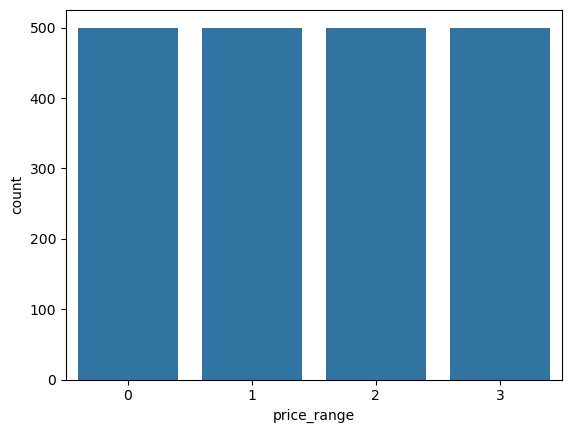

In [21]:
#Target Variable Analysis
sns.countplot(x='price_range', data=df)
plt.show()

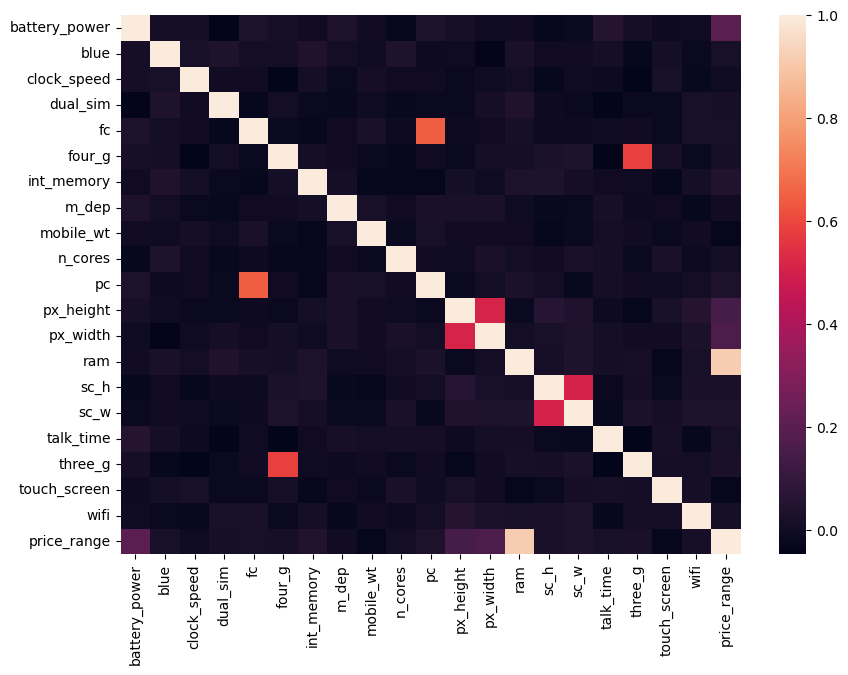

In [38]:
#Correlation Heatmap
plt.figure(figsize=(10,7))

sns.heatmap(df.corr())

plt.show()

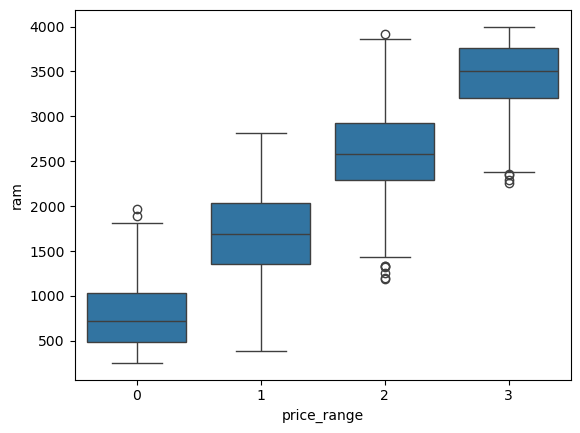

In [24]:
#RAM vs Price Range : To understand whether RAM affects mobile pricing and identify its importance in price prediction.
sns.boxplot(x='price_range', y='ram', data=df)
plt.show()

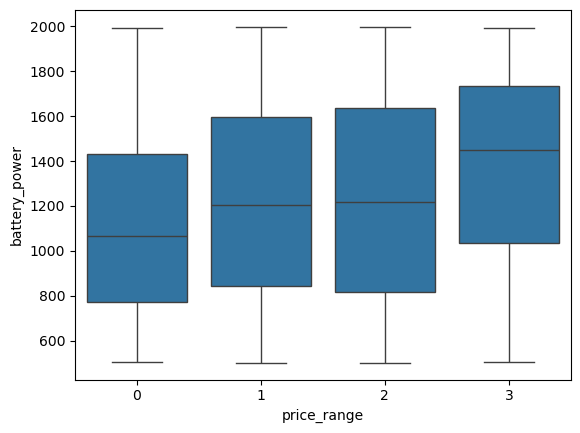

In [18]:
# Battery vs Price Range
sns.boxplot(x='price_range', y='battery_power', data=df)
plt.show()

## Feature Selection

In [29]:
# Machine learning models require input features (X) and target variable (y) separately for training and prediction.

X = df.drop('price_range', axis=1)
y = df['price_range']

## Train-Test Split

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,   #20% test data
    random_state=42,  # everytime will get same split ,use for reproducibility
    stratify=y  #Stratify ensure that training & testing both maintain balanced. maintain the same proportion of all price categories.
)

## Check spilt

In [28]:
print(X_train.shape)

print(X_test.shape)

(1600, 20)
(400, 20)


## Feature Scaling

In [31]:
# To bring all features onto a common scale and improve the performance of distance-based and optimization-based algorithms.
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test) # not use fit cause test data to be unseen

## Logistic Regression

- Logistic Regression is simple, fast and works well on classification problems.
- It provides a strong baseline model.

In [49]:
lr = LogisticRegression(max_iter=3000)

lr.fit(X_train_scaled, y_train)

pred_lr = lr.predict(X_test_scaled)

lr_acc = accuracy_score(y_test, pred_lr) #total number of correct predictions divided by the total number of predictions.

print(lr_acc)

0.965


## Decision Tree

- Decision Trees are interpretable and can capture non-linear relationships.

In [50]:
dt = DecisionTreeClassifier( random_state=42 )

dt.fit(X_train, y_train)

pred_dt = dt.predict(X_test)

dt_acc = accuracy_score(y_test, pred_dt)

print(dt_acc)

0.83


## Random Forest

- Random Forest combines multiple decision trees and reduces overfitting while improving prediction performance.

In [51]:
rf = RandomForestClassifier(
    n_estimators=200,   # build 200 trees
    random_state=42
)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

rf_acc = accuracy_score(y_test, pred_rf)

print(rf_acc)

0.8775


## KNN (K Nearest Neighbors)

In [52]:
knn = KNeighborsClassifier(
    n_neighbors=5
)

knn.fit(X_train_scaled, y_train)

pred_knn = knn.predict(X_test_scaled)

knn_acc = accuracy_score(y_test, pred_knn)

print(knn_acc)

0.5


## Model Evaluation

In [54]:
print("Logistic Regression:", lr_acc)
print("Decision Tree:", dt_acc)
print("Random Forest:", rf_acc)
print("KNN:", knn_acc)

Logistic Regression: 0.965
Decision Tree: 0.83
Random Forest: 0.8775
KNN: 0.5


## Classification Report

In [55]:
print(
    classification_report(
        y_test,
        pred_rf
    )
)

              precision    recall  f1-score   support

           0       0.94      0.95      0.95       100
           1       0.81      0.84      0.82       100
           2       0.82      0.79      0.81       100
           3       0.94      0.93      0.93       100

    accuracy                           0.88       400
   macro avg       0.88      0.88      0.88       400
weighted avg       0.88      0.88      0.88       400



## Confusion Matrix

In [57]:
cm = confusion_matrix(
    y_test,
    pred_rf
)

print(cm)

[[95  5  0  0]
 [ 6 84 10  0]
 [ 0 15 79  6]
 [ 0  0  7 93]]


| Actual ↓ / Predicted → | 0  | 1  | 2  | 3  |
| ---------------------- | -- | -- | -- | -- |
| **0 (Low)**            | 95 | 5  | 0  | 0  |
| **1 (Medium)**         | 6  | 84 | 10 | 0  |
| **2 (High)**           | 0  | 15 | 79 | 6  |
| **3 (Premium)**        | 0  | 0  | 7  | 93 |


## Feature Importance Analysis

- Feature importance indicates how much each feature contributes to the model's prediction.

- Higher importance means the feature has a stronger influence on the target variable.

In [59]:
importance = rf.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
})

feature_importance.sort_values(
    by='Importance',
    ascending=False,
    inplace=True
)

feature_importance.head(10)

,Feature,Importance
13,ram,0.482913
0,battery_power,0.072960
12,px_width,0.057762
11,px_height,0.055650
8,mobile_wt,0.038956
6,int_memory,0.035032
16,talk_time,0.030427
10,pc,0.029901
15,sc_w,0.028026
2,clock_speed,0.027638


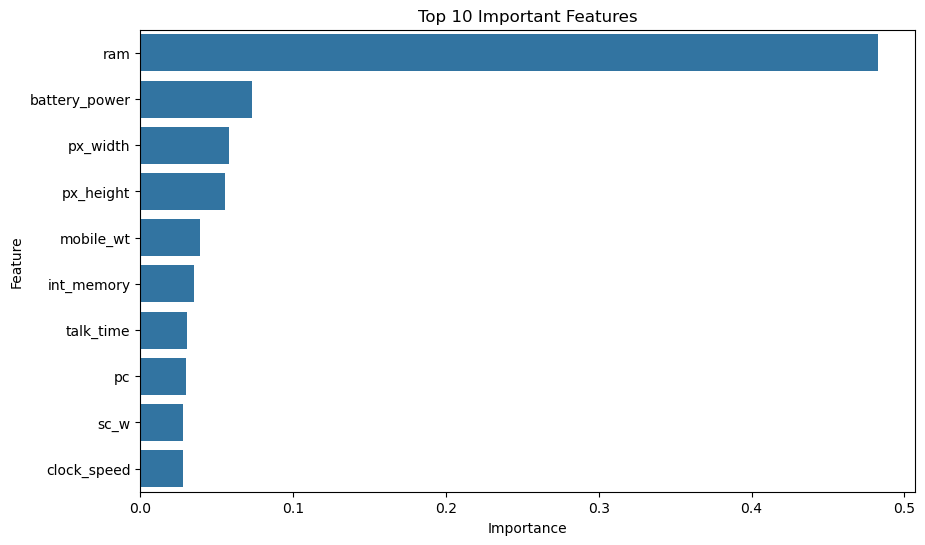

In [61]:
# Visualization

plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance.head(10)
)

plt.title("Top 10 Important Features")

plt.show()

## 📊 Business Insights

### 🎯 Objective
The objective of this project was to predict the mobile phone price range based on various hardware and technical specifications. After performing Exploratory Data Analysis (EDA) and building multiple machine learning models, the following key business insights were identified.

---

### 1️⃣ RAM is the Most Important Feature
- RAM showed the strongest relationship with mobile price range.
- Phones with higher RAM capacity were generally classified into higher price categories.
- This indicates that RAM is one of the primary factors influencing smartphone pricing.

**Business Impact:**  
Manufacturers aiming to launch premium smartphones should focus on increasing RAM capacity.

---

### 2️⃣ Battery Power Positively Influences Price
- Higher battery capacity was commonly observed in expensive smartphones.
- Premium devices generally offer better battery backup and performance.

**Business Impact:**  
Improving battery specifications can increase the perceived value of a smartphone and support premium pricing.

---

### 3️⃣ Display Resolution Plays a Significant Role
- Features such as `px_height` and `px_width` contributed significantly to price prediction.
- Smartphones with better display quality were often categorized into higher price ranges.

**Business Impact:**  
Investing in higher-resolution displays can help position products in premium market segments.

---

### 4️⃣ Internal Memory Contributes to Higher Pricing
- Devices with larger internal storage tended to belong to higher price categories.
- Customers often associate larger storage capacity with premium devices.

**Business Impact:**  
Providing higher storage variants can improve product value and justify higher pricing.

---

### 5️⃣ Connectivity Features Have Lower Impact
- Features such as WiFi, Bluetooth, and Dual SIM showed relatively lower influence on price prediction.
- These features are now common across most smartphone categories.

**Business Impact:**  
Connectivity features alone are not strong differentiators for pricing strategies.

---

## 📈 Business Recommendations

✅ Focus on increasing RAM and storage capacity for premium smartphones.

✅ Improve battery performance to enhance customer satisfaction and market competitiveness.

✅ Invest in better display quality and screen resolution.

✅ Use the developed machine learning model to estimate the price category of new smartphone designs before market launch.

---

The analysis revealed that hardware specifications such as RAM, battery power, screen resolution, and internal memory are the primary drivers of smartphone pricing. The developed machine learning model can assist manufacturers in designing products, optimizing specifications, and making data-driven pricing decisions.

## Model Comparison Report

| Model | Accuracy |
|---------|---------|
| Logistic Regression | 96.5% |
| Decision Tree | 83% |
| Random Forest | 87.75% |
| KNN | 5% |

### Observation :

- Logistic Regression achieved the highest accuracy among all evaluated models.

- Random Forest also performed well but was slightly less accurate.

- Decision Tree provided acceptable performance but showed signs of overfitting.

- KNN achieved the lowest accuracy on this dataset.

Therefore, Logistic Regression is recommended for production deployment.

## ⚠️ Challenges Faced and Solutions

## 🎯 Overview

During the development of the Cellphone Price Range Prediction project, several challenges were encountered while analyzing the dataset and building machine learning models. Appropriate techniques were applied to overcome these challenges and improve model performance.

---

### 🚧 Challenge 1: Understanding Feature Relationships

#### Problem
The dataset contained multiple hardware-related features such as RAM, battery power, internal memory, pixel resolution, WiFi, Bluetooth, and many others. Initially, it was difficult to identify which features had the strongest influence on mobile price range.

#### Solution
Exploratory Data Analysis (EDA) techniques such as:
- Correlation Heatmap
- Boxplots
- Distribution Analysis

were used to understand relationships between features and the target variable.

#### Outcome
RAM, battery power, screen resolution, and internal memory were identified as the most influential features.

---

### 🚧 Challenge 2: Selecting the Best Machine Learning Model

#### Problem
Multiple machine learning algorithms can be used for classification problems. It was challenging to determine which model would provide the best performance for this dataset.

#### Solution
The following models were trained and evaluated:

- Logistic Regression
- Decision Tree Classifier
- Random Forest Classifier
- K-Nearest Neighbors (KNN)

Performance was compared using:
- Accuracy Score
- Classification Report
- Confusion Matrix

#### Outcome
Logistic Regression achieved the highest accuracy and was selected as the final model.

---

### 🚧 Challenge 3: Feature Scaling Requirements

#### Problem
Different features had different value ranges.

Examples:
- RAM: 256 to 4000
- Battery Power: 500 to 2000
- WiFi: 0 or 1

This could negatively affect distance-based algorithms.

#### Solution
StandardScaler was applied to normalize the feature values before training Logistic Regression and KNN models.

#### Outcome
Scaling improved model stability and ensured fair feature contribution.

---

### 🚧 Challenge 4: Model Misclassification Between Similar Categories

#### Problem
The model occasionally confused neighboring price categories such as:

- Medium Cost and High Cost
- High Cost and Very High Cost

because their specifications were often similar.

#### Solution
Confusion Matrix analysis was performed to identify where misclassifications occurred and understand model behavior.

#### Outcome
The model rarely confused Low Cost phones with Premium phones, indicating strong overall classification capability.

---

### 🚧 Challenge 5: Interpreting Model Results

#### Problem
Achieving a high accuracy score alone was not sufficient. Business stakeholders also needed to understand which features influenced price prediction.

#### Solution
Feature Importance analysis was performed using Random Forest.

#### Outcome
The analysis clearly showed that:
- RAM
- Battery Power
- Screen Resolution
- Internal Memory

were the most significant factors affecting mobile price range.

---

### ✅ Final Outcome

All identified challenges were successfully addressed using data analysis, preprocessing, model comparison, and feature importance techniques. The final machine learning model achieved strong predictive performance and provided valuable business insights for smartphone pricing decisions.

## Conclusion

- The objective of this project was to develop a machine learning model capable of predicting the price range of mobile phones based on their hardware and technical specifications.

- A complete Exploratory Data Analysis (EDA) was performed to understand the dataset and identify important features affecting mobile pricing.

- Multiple machine learning algorithms including Logistic Regression, Decision Tree, Random Forest, and KNN were trained and evaluated.

- Among all models, Logistic Regression achieved the best performance and demonstrated strong predictive capability.

- The analysis revealed that RAM, battery power, screen resolution, and internal memory are the most influential factors affecting mobile phone pricing.

- The developed model can assist smartphone manufacturers in estimating product price categories, optimizing device specifications, and making data-driven business decisions before launching new products into the market.

- This project successfully achieved its objective and demonstrated the practical application of machine learning in product pricing and market analysis.